# Data Tranformation(DGS_Reduction)

# Load data as Scipp DataArray (McStasToX)

In [1]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)


data_path = parent + "/runs/TREX_vanad_1e11"

In [ ]:
from dgs_reduction import merge_data

events_binned, det_positions = merge_data(
    data_path, source_name="ESS_source", sample_name="Sample"
)
display(events_binned)

Found 1 data files in /Users/bingli/GitHub/md_norm/runs/TREX_vanad_1e11


<scipp.DataArray>
Dimensions: Sizes[pixel_id:31680, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 31678, 31679]
* position                  vector3              [m]  (pixel_id)  [(-0.904187, -1.0875, 166.263), (-0.88276, -1.0875, 166.278), ..., (2.60711, 1.0875, 161.398), (2.58595, 1.0875, 161.382)]
* sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 7011627),
          data=float64[counts],
          coords={'t':float64[s]})

The events are binned by pixel_id, only pixels with events recored are saved in data. This allows for masking by pixel_id 

In [4]:
# #events_binned = scipp_data_group["events"]
# display(events_binned)
# sample_position = events_binned.coords["sample_position"]

# # mask back scattering pixels
# mask = events_binned.coords["position"].fields.z > sample_position.fields.z
# # events_binned = events_binned[mask]

In [5]:
# frac_forward = sc.sum(mask).value / len(mask)
# frac_forward

# Read in Monitor data (McStasScript/McStasToX)

In [6]:
import mcstasscript as ms
from reduction.dgs_reduction import monitor_multi_pulse

monitor_data_path = data_path

mcstas_data = ms.load_data(monitor_data_path)
presample_monitor_data = ms.name_search("P_monitor_ToF_2", mcstas_data)
monitor_data = monitor_multi_pulse(
    presample_monitor_data, rrm=8, threshold_fraction=0.02, unit="s"
)


  Expected ~8 frames (RRM=8)
  Detected 7 peaks
  Min distance used: 1 bins (0.0 s)
    Peak  0: t=0.17 s  counts=8.238e+04
    Peak  1: t=0.18 s  counts=2.332e+05
    Peak  2: t=0.19 s  counts=1.945e+05
    Peak  3: t=0.20 s  counts=1.628e+05
    Peak  4: t=0.21 s  counts=1.367e+05
    Peak  5: t=0.22 s  counts=1.154e+05
    Peak  6: t=0.23 s  counts=3.478e+04


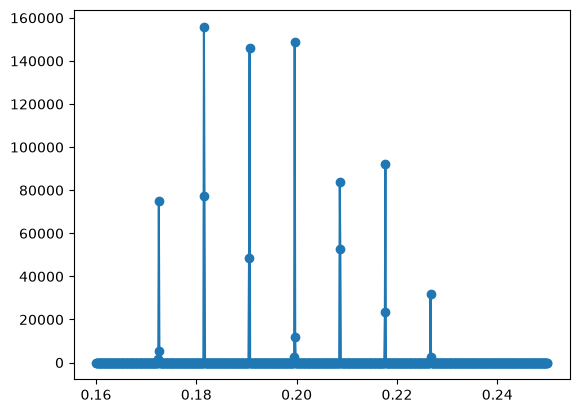

In [7]:
import numpy as np
import matplotlib.pyplot as plt

intensity = np.asarray(
    presample_monitor_data.Intensity, dtype=float
)  # intensity in monitor
xaxis = np.asarray(presample_monitor_data.xaxis, dtype=float)
plt.plot(xaxis, intensity, "-o")

In [8]:
with mx.Read(data_path) as mcstas_data:
    presample_monitor_position = mcstas_data.get_global_component_coordinates(
        component_name="P_monitor_ToF_2"
    )

monitor_data.coords["presample_monitor_position"] = sc.vector(
    value=presample_monitor_position, unit="m"
)
monitor_data.coords["source_position"] = events_binned.coords.pop("source_position")
monitor_data.coords["sample_position"] = events_binned.coords.pop("sample_position")

# Calculate Ei per RRM

<scipp.DataArray>
Dimensions: Sizes[rrm:7, ]
Coordinates:
* ei                        float64            [meV]  (rrm)  [4.80563, 4.33565, ..., 3.00671, 2.77048]
* ki                        vector3           [1/Å]  (rrm)  [(0.00771773, 0, 1.52286), (0.00733064, 0, 1.44648), ..., (0.00610465, 0, 1.20457), (0.00585993, 0, 1.15628)]
  presample_monitor_position  vector3              [m]  ()  (0.830123, 0, 163.8)
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
  source_position           vector3              [m]  ()  (0, 0, 0)
  time_on_monitor           float64              [s]  (rrm)  [0.172533, 0.181554, ..., 0.217674, 0.226693]
* time_on_sample            float64              [s]  (rrm)  [0.172549, 0.181571, ..., 0.217694, 0.226714]
  time_on_source            float64              [s]  ()  0.0017
Data:
                            float64         [counts]  (rrm)  [82381.8, 233214, ..., 115435, 34775.7]

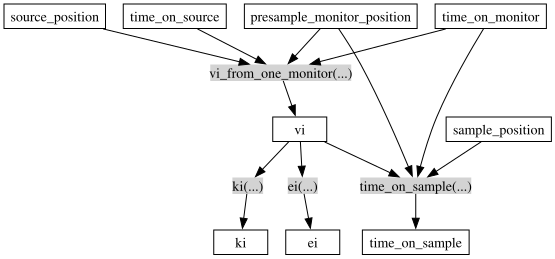

In [9]:
from dgs_reduction import calculate_ei

monitor_data.coords["time_on_source"] = sc.scalar(value=1.7, unit="ms").to(unit="s")

monitor_data = monitor_data.transform_coords(
    ["ki", "ei", "time_on_sample"],
    graph=calculate_ei,
    keep_intermediate=False,
)
display(monitor_data)
sc.show_graph(calculate_ei)

# Calculate the INS time windows (per pixel, per RRM)
By defualt, keep events where energy transfer E = Ei - Ef is within ±0.8*Ei. Events outside this range will be masked later. Notice that sample to detector distance varys, so the TOA windows are different per pxiel_id, per RRM.

In [10]:
from dgs_reduction import determine_INS_windows

norm_factors = determine_INS_windows(
    monitor_data, det_positions, energy_transfer_ratio=(-0.8, 0.8)
)
display(norm_factors)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:31680, rrm:7, ]
Coordinates:
* detector_positions        vector3              [m]  (pixel_id)  [(-0.904187, -1.0875, 166.263), (-0.88276, -1.0875, 166.278), ..., (2.60711, 1.0875, 161.398), (2.58595, 1.0875, 161.382)]
* ei                        float64            [meV]  (rrm)  [4.80563, 4.33565, ..., 3.00671, 2.77048]
* ki                        vector3           [1/Å]  (rrm)  [(0.00771773, 0, 1.52286), (0.00733064, 0, 1.44648), ..., (0.00610465, 0, 1.20457), (0.00585993, 0, 1.15628)]
* monitor_counts            float64         [counts]  (rrm)  [82381.8, 233214, ..., 115435, 34775.7]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* time_on_sample            float64              [s]  (rrm)  [0.172549, 0.181571, ..., 0.217694, 0.226714]
* toa_max                   float64              [s]  (pixel_id, rrm)  [0.179991, 0.189405, ..., 0.227102, 0.236515]
* toa_min                   float64              [s]  (pixel_id, rrm)  [0.175029, 0.184182, ..., 0.22083, 0.229981]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Flatten the binned events, add pixel_id as coordinate

In [11]:
events_binned.bins.coords["pixel_id"] = sc.bins_like(
    events_binned.data, events_binned.coords["pixel_id"]
)
events = events_binned.bins.concat().value.copy()
events.coords["toa"] = events.coords.pop("t")
display(events)

<scipp.DataArray>
Dimensions: Sizes[events:7011627, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 31679, 31679]
* toa                       float64              [s]  (events)  [0.221844, 0.231164, ..., 0.17591, 0.221914]
Data:
                            float64         [counts]  (events)  [6.91464e-06, 7.83024e-06, ..., 0.000805576, 0.000233767]

# Assgin RRM index of TOA based on toa_min mask data between toa_max and toa_min

In [12]:
from dgs_reduction import assign_rrm

events = assign_rrm(events, norm_factors)
events

<scipp.DataArray>
Dimensions: Sizes[events:7011627, ]
Coordinates:
* detector_positions        vector3              [m]  (events)  [(-0.904187, -1.0875, 166.263), (-0.904187, -1.0875, 166.263), ..., (2.58595, 1.0875, 161.382), (2.58595, 1.0875, 161.382)]
* ei                        float64            [meV]  (events)  [3.00671, 2.77048, ..., 4.80563, 3.00671]
* ki                        vector3           [1/Å]  (events)  [(0.00610465, 0, 1.20457), (0.00585993, 0, 1.15628), ..., (0.00771773, 0, 1.52286), (0.00610465, 0, 1.20457)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 31679, 31679]
* rrm                         int64  [dimensionless]  (events)  [5, 6, ..., 0, 5]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* time_on_sample            float64              [s]  (events)  [0.217694, 0.226714, ..., 0.172549, 0.217694]
* toa                       float64              [s]  (events)  [0.221844, 0.231164, ..., 0.17591, 0.221914]
Data:
                            float64         [counts]  (events)  [6.91464e-06, 7.83024e-06, ..., 0.000805576, 0.000233767]
Masks:
  outside                      bool        <no unit>  (events)  [False, False, ..., False, False]

# Convert from (pixel_id, toa) to (Q, E)

<scipp.DataArray>
Dimensions: Sizes[events:7011627, ]
Coordinates:
  detector_positions        vector3              [m]  (events)  [(-0.904187, -1.0875, 166.263), (-0.904187, -1.0875, 166.263), ..., (2.58595, 1.0875, 161.382), (2.58595, 1.0875, 161.382)]
  ef                        float64            [meV]  (events)  [3.08957, 2.68725, ..., 4.71156, 2.98784]
  ei                        float64            [meV]  (events)  [3.00671, 2.77048, ..., 4.80563, 3.00671]
* en                        float64            [meV]  (events)  [-0.0828616, 0.0832345, ..., 0.0940648, 0.0188711]
* kf                        vector3           [1/Å]  (events)  [(-0.66369, -0.41614, 0.936674), (-0.618971, -0.388101, 0.873561), ..., (0.829657, 0.513894, -1.14951), (0.660685, 0.409232, -0.915393)]
  ki                        vector3           [1/Å]  (events)  [(0.00610465, 0, 1.20457), (0.00585993, 0, 1.15628), ..., (0.00771773, 0, 1.52286), (0.00610465, 0, 1.20457)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 31679, 31679]
  q                         vector3           [1/Å]  (events)  [(0.669795, 0.41614, 0.267896), (0.624831, 0.388101, 0.282722), ..., (-0.821939, -0.513894, 2.67237), (-0.654581, -0.409232, 2.11996)]
* q_mag                     float64           [1/Å]  (events)  [0.832806, 0.788015, ..., 2.84275, 2.25615]
* qx                        float64           [1/Å]  (events)  [0.669795, 0.624831, ..., -0.821939, -0.654581]
* qy                        float64           [1/Å]  (events)  [0.41614, 0.388101, ..., -0.513894, -0.409232]
* qz                        float64           [1/Å]  (events)  [0.267896, 0.282722, ..., 2.67237, 2.11996]
* rrm                         int64  [dimensionless]  (events)  [5, 6, ..., 0, 5]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
  time_on_sample            float64              [s]  (events)  [0.217694, 0.226714, ..., 0.172549, 0.217694]
  toa                       float64              [s]  (events)  [0.221844, 0.231164, ..., 0.17591, 0.221914]
  vf                        vector3            [m/s]  (events)  [(-417.874, -262.011, 589.751), (-389.718, -244.357, 550.014), ..., (522.37, 323.559, -723.755), (415.982, 257.661, -576.352)]
Data:
                            float64         [counts]  (events)  [6.91464e-06, 7.83024e-06, ..., 0.000805576, 0.000233767]
Masks:
  outside                      bool        <no unit>  (events)  [False, False, ..., False, False]

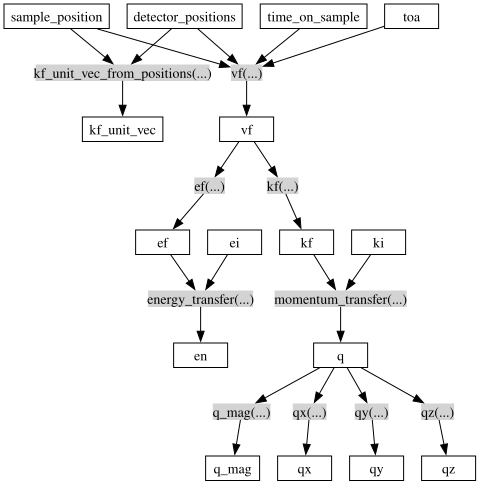

In [13]:
from dgs_reduction import calculate_qe

events = events.transform_coords(
    ["qx", "qy", "qz", "en", "q_mag", "kf"],
    graph=calculate_qe,
    keep_intermediate=True,
)
display(events)
sc.show_graph(calculate_qe)

# Plot events to check for coverage
Notice here we do not ditinguish diffferent RRMs, all events are used for histogramming

In [14]:
%matplotlib widget
import plopp as pp
from dgs_reduction import generate_bins, generate_plot_coords_and_title

grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (-0.2, 0.2),
}

bins = generate_bins(grid)
display(bins)

plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)


{'qx': <scipp.Variable> (qx: 36)    float64           [1/Å]  [-2, -1.9, ..., 1.4, 1.5],
 'qy': <scipp.Variable> (qy: 41)    float64           [1/Å]  [-2, -1.9, ..., 1.9, 2],
 'qz': <scipp.Variable> (qz: 2)    float64           [1/Å]  [-1, 1],
 'en': <scipp.Variable> (en: 2)    float64            [meV]  [-0.2, 0.2]}

<scipp.DataArray>
Dimensions: Sizes[qx:35, qy:40, qz:1, en:1, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-0.2, 0.2]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2, -1.9, ..., 1.4, 1.5]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-2, -1.9, ..., 1.9, 2]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-1, 1]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

In [15]:
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    title=plot_title,
    vmin=0,
    vmax=1e1,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [16]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 2.5),
    "en": (-1, 1, 0.01),
}

bins = generate_bins(grid)
plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)


<scipp.DataArray>
Dimensions: Sizes[qx:35, qy:1, qz:1, en:200, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-1, -0.99, ..., 0.99, 1]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2, -1.9, ..., 1.4, 1.5]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, 2.5]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

In [17]:
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=10,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Calculate normalization factors for histogramming (MDNorm)

# Calculate detector solid angles from a white beam Vanadium run (counts per pixel)

In [18]:
van_path = parent + "/runs/TREX_vanad_1e11"

with mx.Read(van_path) as mcstas_van_data:
    scipp_van_data_group = mcstas_van_data.export_scipp(
        source_name="ESS_source",
        sample_name="Sample",
    )

v_events_binned = scipp_van_data_group["events"]
display(v_events_binned)
# Group by pixel_id to fill in the pixels that recorded no events
detector_posisitions = scipp_van_data_group["positions"]
sample_position = v_events_binned.coords["sample_position"]
v_events = v_events_binned.group(
    sc.arange(detector_posisitions.dim, 0, detector_posisitions.size)
)
display(v_events)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:31680, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 31678, 31679]
* position                  vector3              [m]  (pixel_id)  [(-0.904187, -1.0875, 166.263), (-0.88276, -1.0875, 166.278), ..., (2.60711, 1.0875, 161.398), (2.58595, 1.0875, 161.382)]
* sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 7011627),
          data=float64[counts],
          coords={'t':float64[s]})

<scipp.DataArray>
Dimensions: Sizes[pixel_id:31680, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 31678, 31679]
* sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 7011627),
          data=float64[counts],
          coords={'t':float64[s]})

# Mask the leakage from beamstop

In [19]:
import numpy as np

d_omega_exp = v_events.hist().data
# mask = d_omega_exp > sc.scalar(0.0015, unit=d_omega_exp.unit)
# d_omega_exp = sc.where(mask, sc.scalar(np.nan, unit=d_omega_exp.unit), d_omega_exp)

d_omega_exp /= d_omega_exp.nansum()
print(d_omega_exp)
# norm_factors.coords["d_omega_exp"] = d_omega

<scipp.Variable> (pixel_id: 31680)    float64  [dimensionless]  [3.02803e-05, 3.0439e-05, ..., 2.55547e-05, 3.15511e-05]


# Visualize the Vanadium data

In [20]:
import plopp as pp

theta_bins = 360
theta_limits = [-36, 144]
y_bins = 88
yheight = 2.2

nx, ny = theta_bins, y_bins
v_cylinder = sc.DataArray(
    data=sc.Variable(
        dims=["height", "two_theta"], values=np.reshape(d_omega_exp.values, (ny, nx))
    ),
    coords={
        "two_theta": sc.linspace(
            dim="two_theta", start=theta_limits[0], stop=theta_limits[1], num=nx
        ),
        "height": sc.linspace(
            dim="height", start=-yheight / 2, stop=yheight / 2, num=ny
        ),
    },
)

pp.plot(
    v_cylinder, title="Vanadium cylinder", vmin=0, vmax=1e-4, cmap="turbo", grid=True
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

<scipp.DataArray>
Dimensions: Sizes[pixel_id:31680, ]
Coordinates:
  detector_geometry          string        <no unit>  ()  "cylinder"
  pixel_height              float64              [m]  ()  0.025
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 31678, 31679]
  pixel_position            vector3              [m]  (pixel_id)  [(-1.73442, -1.0875, 2.44781), (-1.713, -1.0875, 2.46285), ..., (1.77688, 1.0875, -2.41717), (1.75572, 1.0875, -2.43258)]
* pixel_solid_angle         float64             [sr]  (pixel_id)  [6.04271e-05, 6.04271e-05, ..., 6.04271e-05, 6.04271e-05]
  pixel_width               float64              [m]  ()  0.0261799
* sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 7011627),
          data=float64[counts],
          coords={'t':float64[s]})

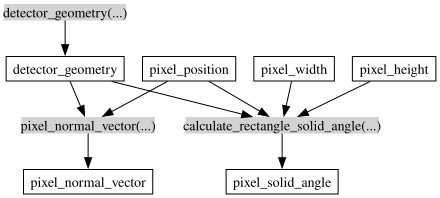

In [21]:
from reduction.dgs_reduction import calculate_solid_angle

h = sc.norm(detector_posisitions[theta_bins] - detector_posisitions[0])
w = sc.norm(detector_posisitions[1] - detector_posisitions[0])
r = detector_posisitions - sample_position

v_events.coords["pixel_position"] = r
v_events.coords["pixel_height"] = h
v_events.coords["pixel_width"] = w
v_events = v_events.transform_coords(
    [
        "pixel_solid_angle",
    ],
    graph=calculate_solid_angle,
)
display(v_events)
sc.show_graph(calculate_solid_angle)

In [22]:
pp.plot(
    {
        "McStas": d_omega_exp,
        "Calc": v_events.coords["pixel_solid_angle"]
        / sc.sum(v_events.coords["pixel_solid_angle"]),
    },
    ylabel="fractional counts",
    title="Vanadium counts/pixel over total counts",
    linestyle="-",
    markersize=2,
    # ymax=2e-5,
    ymin=0.0,
    grid=True,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [23]:
norm_factors.coords["d_omega"] = v_events.coords["pixel_solid_angle"]
norm_factors

<scipp.DataArray>
Dimensions: Sizes[pixel_id:31680, rrm:7, ]
Coordinates:
* d_omega                   float64             [sr]  (pixel_id)  [6.04271e-05, 6.04271e-05, ..., 6.04271e-05, 6.04271e-05]
* detector_positions        vector3              [m]  (pixel_id)  [(-0.904187, -1.0875, 166.263), (-0.88276, -1.0875, 166.278), ..., (2.60711, 1.0875, 161.398), (2.58595, 1.0875, 161.382)]
* ei                        float64            [meV]  (rrm)  [4.80563, 4.33565, ..., 3.00671, 2.77048]
* ki                        vector3           [1/Å]  (rrm)  [(0.00771773, 0, 1.52286), (0.00733064, 0, 1.44648), ..., (0.00610465, 0, 1.20457), (0.00585993, 0, 1.15628)]
* monitor_counts            float64         [counts]  (rrm)  [82381.8, 233214, ..., 115435, 34775.7]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* time_on_sample            float64              [s]  (rrm)  [0.172549, 0.181571, ..., 0.217694, 0.226714]
* toa_max                   float64              [s]  (pixel_id, rrm)  [0.179991, 0.189405, ..., 0.227102, 0.236515]
* toa_min                   float64              [s]  (pixel_id, rrm)  [0.175029, 0.184182, ..., 0.22083, 0.229981]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Calculate detector trajectory endpoints (per pixel, per RRM)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:31680, rrm:7, ]
Coordinates:
* d_omega                   float64             [sr]  (pixel_id)  [6.04271e-05, 6.04271e-05, ..., 6.04271e-05, 6.04271e-05]
  detector_positions        vector3              [m]  (pixel_id)  [(-0.904187, -1.0875, 166.263), (-0.88276, -1.0875, 166.278), ..., (2.60711, 1.0875, 161.398), (2.58595, 1.0875, 161.382)]
  ef_gain                   float64            [meV]  (pixel_id, rrm)  [8.65013, 7.80417, ..., 5.41208, 4.98687]
  ef_loss                   float64            [meV]  (pixel_id, rrm)  [0.961125, 0.86713, ..., 0.601342, 0.554097]
  ei                        float64            [meV]  (rrm)  [4.80563, 4.33565, ..., 3.00671, 2.77048]
* energy_gain_ratio         float64  [dimensionless]  (pixel_id, rrm)  [-0.8, -0.8, ..., -0.8, -0.8]
* energy_loss_ratio         float64  [dimensionless]  (pixel_id, rrm)  [0.8, 0.8, ..., 0.8, 0.8]
* kf_M                      vector3           [1/Å]  (pixel_id, rrm)  [(-1.11052, -0.696309, 1.56729), (-1.05482, -0.661385, 1.48868), ..., (0.889197, 0.550773, -1.232), (0.853552, 0.528694, -1.18261)]
  kf_M_mag                  float64           [1/Å]  (pixel_id, rrm)  [2.04316, 1.94069, ..., 1.61612, 1.55134]
* kf_m                      vector3           [1/Å]  (pixel_id, rrm)  [(-0.370174, -0.232103, 0.522432), (-0.351608, -0.220462, 0.496228), ..., (0.296399, 0.183591, -0.410667), (0.284517, 0.176231, -0.394205)]
  kf_m_mag                  float64           [1/Å]  (pixel_id, rrm)  [0.681055, 0.646895, ..., 0.538707, 0.517112]
  kf_unit_vec               vector3  [dimensionless]  (pixel_id)  [(-0.543531, -0.340799, 0.767092), (-0.536816, -0.340799, 0.771806), ..., (0.556836, 0.340799, -0.757489), (0.550204, 0.340799, -0.76232)]
  ki                        vector3           [1/Å]  (rrm)  [(0.00771773, 0, 1.52286), (0.00733064, 0, 1.44648), ..., (0.00610465, 0, 1.20457), (0.00585993, 0, 1.15628)]
* monitor_counts            float64         [counts]  (rrm)  [82381.8, 233214, ..., 115435, 34775.7]
* q_M                       vector3           [1/Å]  (pixel_id, rrm)  [(1.11824, 0.696309, -0.0444295), (1.06215, 0.661385, -0.0422011), ..., (-0.883093, -0.550773, 2.43657), (-0.847692, -0.528694, 2.3389)]
* q_m                       vector3           [1/Å]  (pixel_id, rrm)  [(0.377892, 0.232103, 1.00043), (0.358938, 0.220462, 0.950255), ..., (-0.290294, -0.183591, 1.61524), (-0.278657, -0.176231, 1.55049)]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
  time_on_sample            float64              [s]  (rrm)  [0.172549, 0.181571, ..., 0.217694, 0.226714]
  toa_max                   float64              [s]  (pixel_id, rrm)  [0.179991, 0.189405, ..., 0.227102, 0.236515]
  toa_min                   float64              [s]  (pixel_id, rrm)  [0.175029, 0.184182, ..., 0.22083, 0.229981]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

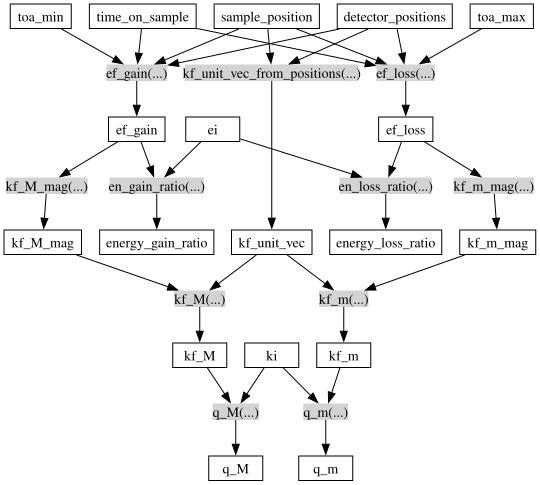

In [24]:
from dgs_reduction import calculate_trajectory_endpoints

norm_factors = norm_factors.transform_coords(
    [
        "energy_gain_ratio",
        "energy_loss_ratio",
        "kf_m",
        "kf_M",
        "q_m",
        "q_M",
    ],
    graph=calculate_trajectory_endpoints,
)
display(norm_factors)
sc.show_graph(calculate_trajectory_endpoints)

In [25]:
from dgs_reduction import mdnorm

grid = {
    "qx": (-3, 3, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (-0.2, 0.2),
}

rrm = 0
data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [26]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=1e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [27]:
grid = {
    "qx": (-3, 3, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (2.0, 2.2),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [28]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=1e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [29]:
grid = {
    "qx": (-3, 1.5, 0.01),
    "qy": (-0.02, 0.02),
    "qz": (-1, 3.0, 0.02),
    "en": (-0.2, 0.2),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [30]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [31]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-0.1, 0.1),
    "qz": (-1, 3.0, 0.1),
    "en": (2.0, 2.2),
}

data, plot_coords, plot_title = mdnorm(
    events,
    grid,
    norm_factors,
    rrm=rrm,
)

In [32]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# averaging over a large Q ranges is very slow

In [33]:
grid = {
    "qx": (-1.5, 1.0),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 3.5, 0.1),
    "en": (-4, 4, 0.02),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [34]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-3,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Plot a 1D cut

In [35]:
grid = {
    "qx": (-1.5, 1.0),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 2.5),
    "en": (-4, 4, 0.02),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [36]:
data

<scipp.DataArray>
Dimensions: Sizes[en:400, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.98, ..., 3.98, 4]
  qx                        float64           [1/Å]  (qx [bin-edge])  [-1.5, 1]
  qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
  qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, 2.5]
Data:
                            float64       [1/sr/meV]  (en)  [nan, nan, ..., nan, nan]

In [37]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=6e-3,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [38]:
grid = {
    "qx": (-2.5, 2.0, 0.05),
    "qy": (-1.0, 1.0),
    "qz": (-0.0, 1.0),
    "en": (-1.5, 0.5, 0.005),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [39]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=1e-2,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Plot |Q| vs. E for powder samples

In [40]:
grid = {
    "qx": (-3, 3.0, 0.1),
    "qy": (-3.0, 3.0, 0.1),
    "qz": (-3, 3, 0.1),
    "en": (-4, 4, 0.005),
}

data4d, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

mag_q = sc.sqrt(
    sc.midpoints(data4d.coords["qx"]) ** 2
    + sc.midpoints(data4d.coords["qy"]) ** 2
    + sc.midpoints(data4d.coords["qz"]) ** 2
)

data4d.coords["mag_q"] = mag_q
data4d

<scipp.DataArray>
Dimensions: Sizes[en:1600, qz:60, qy:60, qx:60, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.995, ..., 3.995, 4]
* mag_q                     float64           [1/Å]  (qx, qy, qz)  [5.10955, 5.05247, ..., 5.05247, 5.10955]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-3, -2.9, ..., 2.9, 3]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-3, -2.9, ..., 2.9, 3]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-3, -2.9, ..., 2.9, 3]
Data:
                            float64       [1/sr/meV]  (en, qz, qy, qx)  [nan, nan, ..., nan, nan]

In [41]:
q_bins = sc.linspace("mag_q", 0.0, 4.0, num=100, unit="1/Å")
rebinned = data4d.bin(mag_q=q_bins)
data_rebinned = rebinned.bins.nanmean()
display(data_rebinned)

pp.plot(
    data_rebinned,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-3,
    title=plot_title,
)

<scipp.DataArray>
Dimensions: Sizes[en:1600, mag_q:99, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.995, ..., 3.995, 4]
* mag_q                     float64           [1/Å]  (mag_q [bin-edge])  [0, 0.040404, ..., 3.9596, 4]
Data:
                            float64       [1/sr/meV]  (en, mag_q)  [nan, nan, ..., nan, nan]

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…